# This project analyzes retail sales data to understand revenue patterns, profitability issues, and category-level performance to support business decision-making.

#### Import The Necessay Library

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#### Read the Sales Data 

In [2]:
df=pd.read_csv('Sample - Superstore.csv',encoding='cp1252')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


#### Check the Datatypes 

In [6]:
df.dtypes

Row_ID                    int64
Order_ID                    str
Order_Date       datetime64[ns]
Ship_Date                   str
Ship_Mode                   str
Customer_ID                 str
Customer_Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal_Code               int64
Region                      str
Product_ID                  str
Category                    str
Sub-Category                str
Product_Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

#### Since the Date Column in str Change to datetime64 datatype

In [4]:
df['Order_Date']=df['Order_Date'].astype('datetime64[ns]')
df['Order_Date'].dtype

dtype('<M8[ns]')

#### Check if any Null values 

In [4]:
df.isnull().sum()

Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub-Category     0
Product_Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [3]:
df.columns=df.columns.map(lambda x: x.replace(' ','_'))
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

#### Group the Sales by Category

In [5]:
sales_cat=df.groupby('Category')['Sales'].sum()
sales_cat

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

#### Group the Profit by Category

In [6]:
profit_cat=df.groupby('Category')['Profit'].sum()
profit_cat

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

#### Total Quantity Sold

In [7]:
total_sal=df.groupby(['Category'])['Quantity'].sum()
total_sal

Category
Furniture           8028
Office Supplies    22906
Technology          6939
Name: Quantity, dtype: int64

#### Sales Percentage

In [8]:
df['Sales_per']=df['Sales'].apply(lambda x : x/df['Sales'].sum())*100

In [9]:
df.groupby('Category')['Sales_per'].sum().round(2)

Category
Furniture          32.3
Office Supplies    31.3
Technology         36.4
Name: Sales_per, dtype: float64

#### Discount Percentage

In [10]:
df['Discount_per']=df['Discount'].apply(lambda x : x/df['Discount'].sum())*100

In [11]:
df.groupby('Category')['Discount_per'].sum().round(2)

Category
Furniture          23.63
Office Supplies    60.71
Technology         15.66
Name: Discount_per, dtype: float64

#### Profit Percentage

In [12]:
df['Profit_per']=df['Profit'].apply(lambda x : x/df['Profit'].sum())*100

In [13]:
df.groupby('Category')['Profit_per'].sum().round(2)

Category
Furniture           6.44
Office Supplies    42.77
Technology         50.79
Name: Profit_per, dtype: float64

#### Sales Trend Over the Year

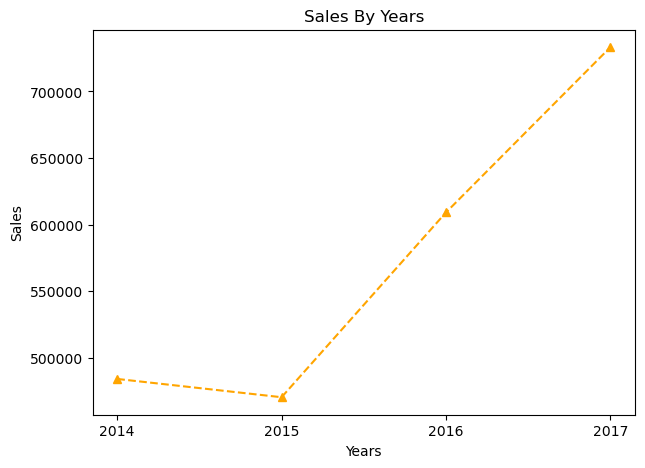

In [152]:
plt.figure(figsize=(7,5))
year=[2014,2015,2016,2017]
plt.plot(df.groupby(df['Order_Date'].dt.year)['Sales'].sum(),marker='^',ls='--',color='Orange')
plt.xticks(year)
plt.xlabel('Years')
plt.ylabel('Sales')
plt.title('Sales By Years')
plt.show()

#### ->it's Clearly seem's that the sales has growth from 2015 to 2017

#### Sales By Months

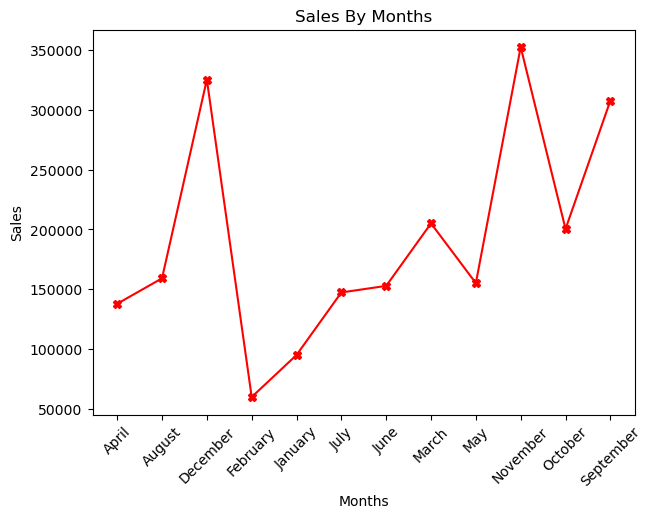

In [17]:
df['Months']=df['Order_Date'].dt.month_name()
plt.figure(figsize=(7,5))
plt.plot(df.groupby('Months')['Sales'].sum(),marker='X',color='red')
plt.xticks(rotation=45)
plt.xlabel('Months')
plt.ylabel('Sales')
plt.title('Sales By Months')
plt.show()

#### -> This Sales by Months Clearly shows that the sales are high perticularly at Nov and Dec
#### -> But,Sales are very at jan and feb 
#### -> We can simply define that Sales are high during the end of year(Nov and Dec) 
####    but the sales are low at year starting(jan and feb) the are normal during the mid of the year

#### Sales VS Profit

Text(0.5, 1.0, 'Profit By Category')

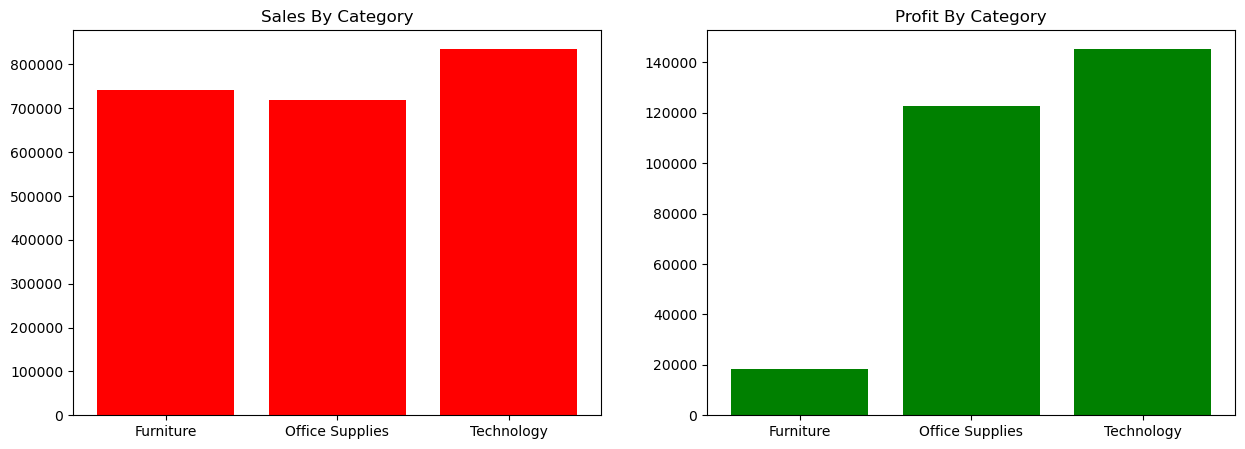

In [134]:
fig , (ax1,ax2) = plt.subplots(1,2,figsize=(15,5))

ax1.bar(sales_cat.index,sales_cat.values,color='red')
ax2.bar(profit_cat.index,profit_cat.values,color='green')

ax1.set_title('Sales By Category')
ax2.set_title('Profit By Category')

### In this Sales vs Profit it's cleary seems that difference between the sales margin are low but When it comes to Profit the difference between the Technology and the Furniture are High   

#### Distribution of Sales Data

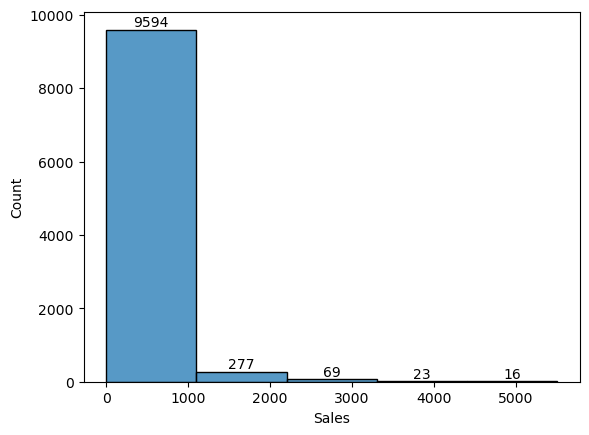

In [18]:
ax=sns.histplot(data=df,x='Sales',bins=5,binrange=(0,5500),)
ax.bar_label(ax.containers[0])
plt.show()

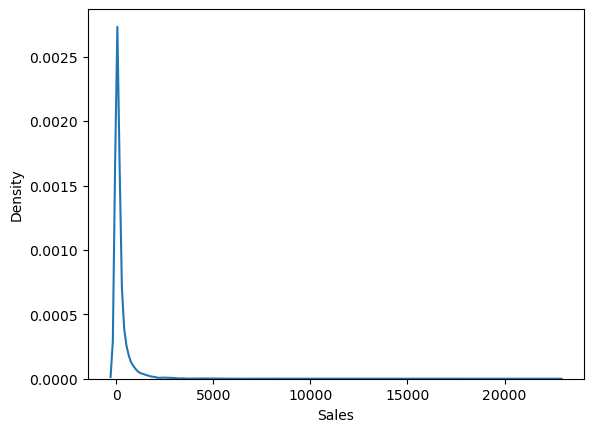

In [167]:
sns.kdeplot(data=df,x='Sales')
plt.show()

#### Relationship Between The Sales and Profit

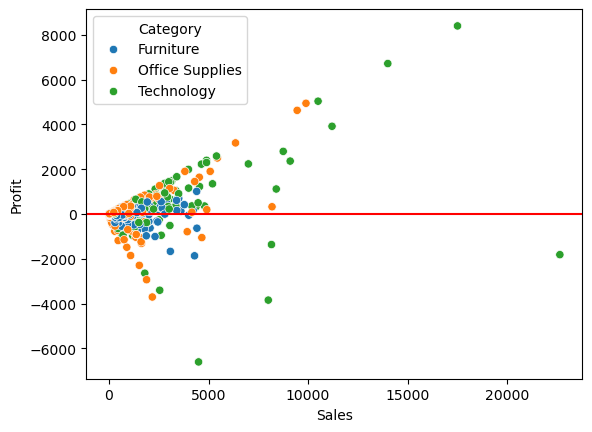

In [29]:
sns.scatterplot(data=df,x='Sales',y='Profit',hue='Category')
plt.axhline(0,color='red')
plt.show()

### -> The Sales and Profit has strong Relation Most of the High Sales has High Profit But, In Some Cases the High Sales has Negative Progit 

#### Profit Vs Discount 

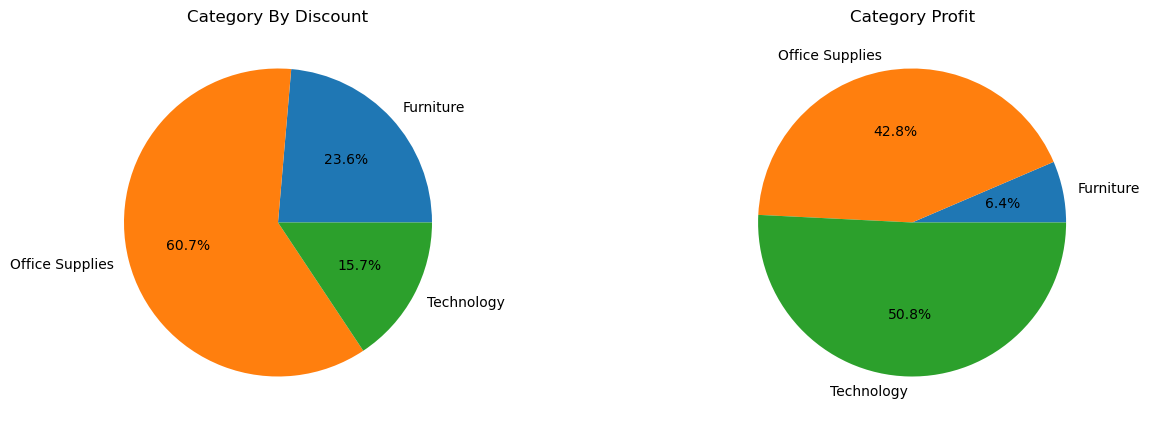

In [20]:
seg=df['Category'].unique()
fig , (ax1,ax2) =plt.subplots(1,2,figsize=(15,5))

ax1.pie(df.groupby('Category')['Discount_per'].sum().round(2),labels=seg,autopct='%1.1f%%')
ax1.set_title('Category By Discount')
ax2.pie(df.groupby('Category')['Profit_per'].sum().round(2),labels=seg,autopct='%1.1f%%')
ax2.set_title('Category Profit')

plt.show()

### When it,s comes to Discount Vs Profit , Furniture has 23.6% Discount & Technology has 15.7% But if you see the Profit the technology has 50.8% profit but Furniture has Just 6.4% Profit , On other hand the Office Supplies has 60.7% Discount The profit is 42.8% 

### The Technology has low Discount and it contribute 50% of the Sales and the office supplies as 60.7% Discount the Profit is 42% it ok but not ideal 

#### Relationship Between Profit,Discount,Quantity,Sales

<Axes: >

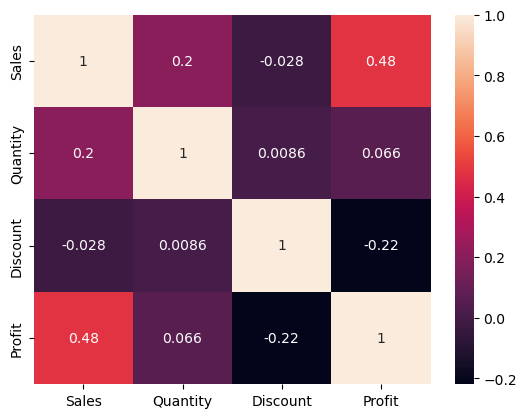

In [29]:
df2=df[['Sales','Quantity','Discount','Profit']]
sns.heatmap(df2.corr(numeric_only=True),annot=True)

### Profit is more Influenced by Sales(Positively) and Discount(Negatively)
### Focus on increasing sales without heavy discounting

#### Distribution of Profit By Category

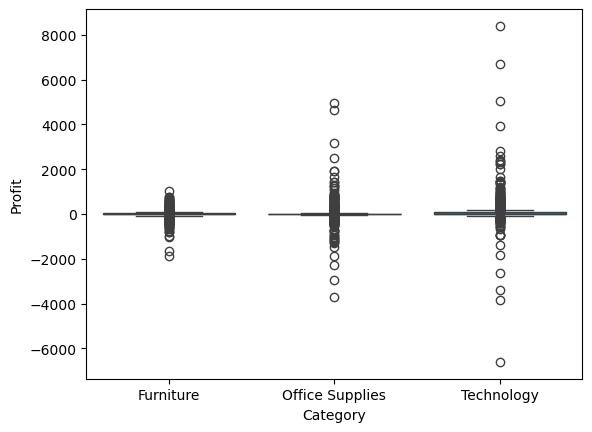

In [19]:
sns.boxplot(data=df,x='Category',y='Profit')
plt.show()

### Since the sales data is highly skewness , let's divided the Sales data into two Range 0-1500 & 1500-5500

In [5]:
sales_under_1500=df[df['Sales']<1500]
sales_above_1500=df[df['Sales']>=1500]

### Let's Find which Category was Sales more in Under 1500 Range

[Text(0, 0, '566324'), Text(0, 0, '535455'), Text(0, 0, '485013')]

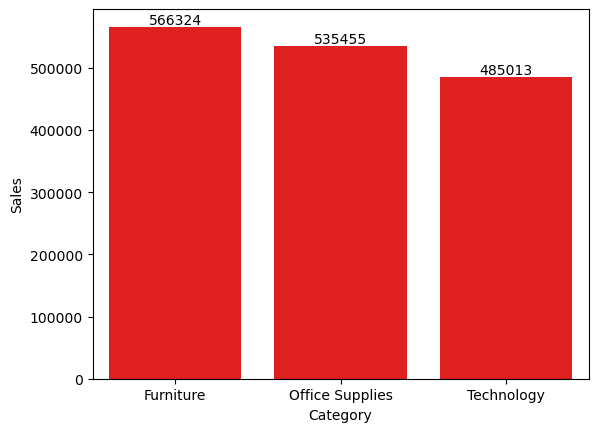

In [11]:
ax=sns.barplot(data=sales_under_1500,x='Category',y='Sales',color='red',estimator=sum,errorbar=None)
ax.bar_label(ax.containers[0])

### ->In the Above Barplot It clearly show that Furniture Sold higher in under_1500 range
### ->The Least sold category in under_1500 is Technology
### ->But,the sales margin don't have any big difference
###

### Let's Find which region and segments Dominet in under_1500

In [17]:
reg_sal_under=sales_under_1500.groupby('Region')['Sales'].sum()
seg_sal_under=sales_under_1500.groupby('Segment')['Sales'].sum()

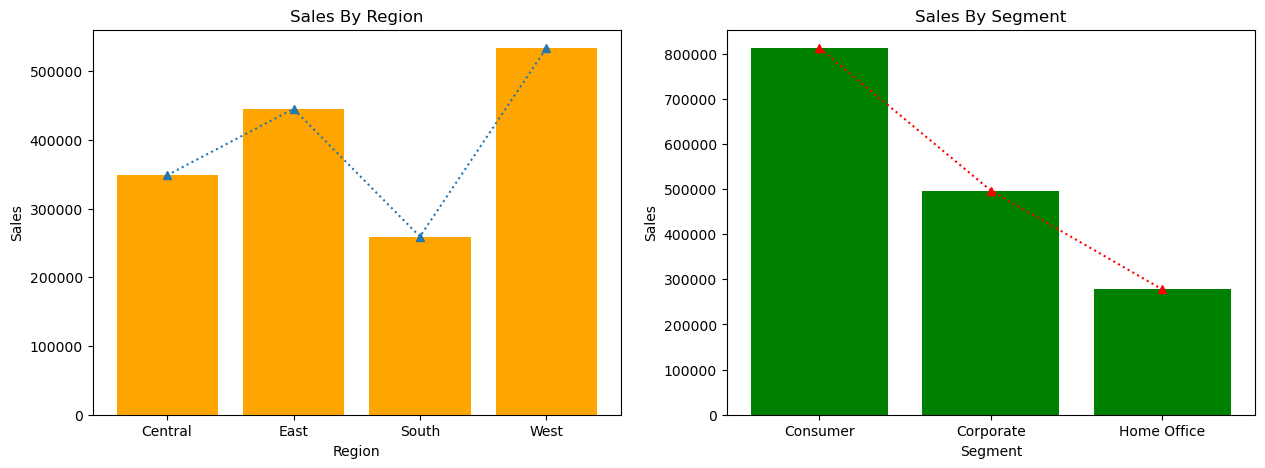

In [18]:
fig , (ax1,ax2) = plt.subplots(1,2,figsize=(15,5))

ax1.bar(reg_sal_under.index,reg_sal_under.values,color='orange')
ax1.plot(reg_sal_under,marker='^',ls=':')
ax1.set_xlabel('Region')
ax1.set_ylabel('Sales')
ax1.set_title('Sales By Region')

ax2.bar(seg_sal_under.index,seg_sal_under.values,color='green')
ax2.plot(seg_sal_under,marker='^',ls=':',color='red')
ax2.set_xlabel('Segment')
ax2.set_ylabel('Sales')
ax2.set_title('Sales By Segment')

plt.show()

### -> under_1500 Category the West is the top region followed by East was second top selling region
### -> Now we can Clearly see that Consumer are the top Segment in under_1500
### -> We need to focus more on the region such as center and south and segments like corporate and home office to improve the over all sales

### Ok, Now let's move on to the above_1500 Division

### Let's Find which Category has more Sales in above_1500  

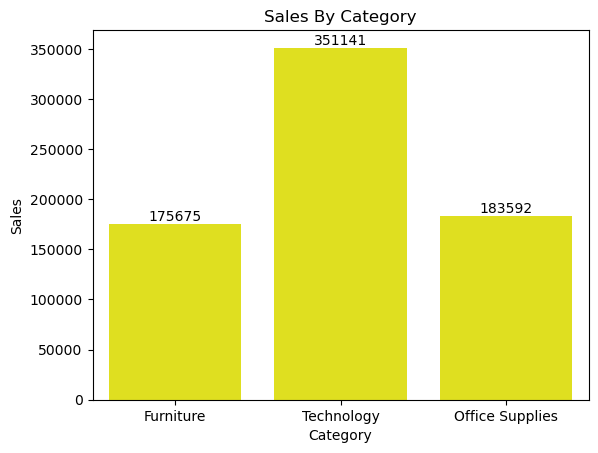

In [10]:
ax=sns.barplot(data=sales_above_1500,x='Category',y='Sales',estimator=sum,errorbar=None,color='yellow')
ax.bar_label(ax.containers[0])
plt.title('Sales By Category')
plt.show()

### -> Here Technology has the highest Sales compare to the other Categories even the Sales Margin is very high
### -> The Category which has the Lowest Sales is Furniture which Performed well in under_1500
###

### Let's Find which region and segments Dominet in above_1500

In [25]:
reg_sal_above=sales_above_1500.groupby('Region')['Sales'].sum()
seg_sal_above=sales_above_1500.groupby('Segment')['Sales'].sum()

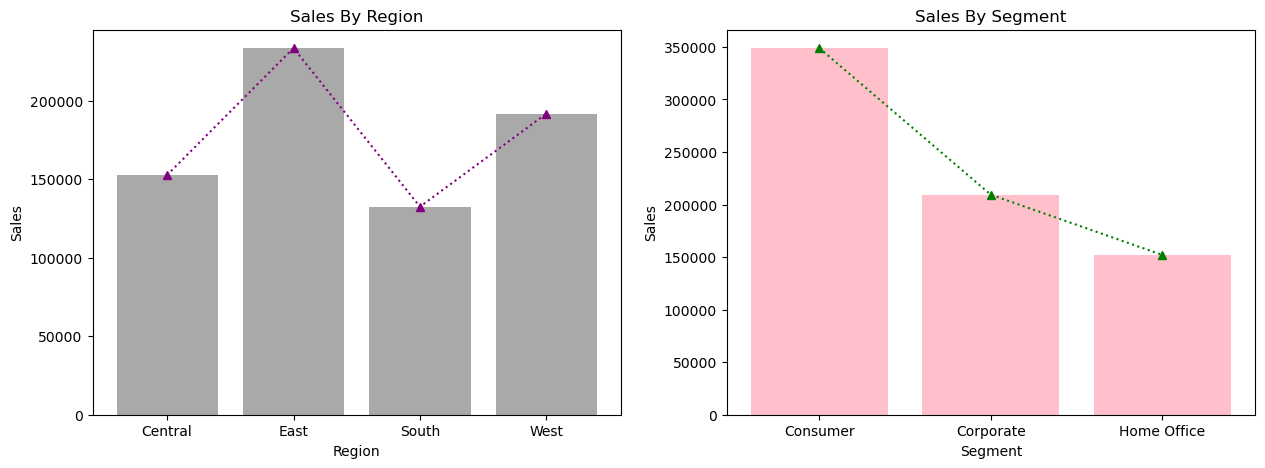

In [33]:
fig , (ax1,ax2) = plt.subplots(1,2,figsize=(15,5))

ax1.bar(reg_sal_above.index,reg_sal_above.values,color='darkgrey')
ax1.plot(reg_sal,marker='^',ls=':',color='purple')
ax1.set_xlabel('Region')
ax1.set_ylabel('Sales')
ax1.set_title('Sales By Region')

ax2.bar(seg_sal_above.index,seg_sal_above.values,color='pink')
ax2.plot(seg_sal,marker='^',ls=':',color='green')
ax2.set_xlabel('Segment')
ax2.set_ylabel('Sales')
ax2.set_title('Sales By Segment')

plt.show()

### -> East and West are the well Performed Region in the above_1500 
### ->Consumer has the hightes sales in Segment

### Here is the Important Notable thing , after analysing both the under_1500 and above_1500 we can clearly see that East & West are the well Performed Region in both under_1500 and above_1500 same for the Consumer Segment has High Sales in both

### Things need to be Focus:
#### > Try to improve Sales on central ans south Region same goes for the Corporate & Home Office Segent
#### > In under_1500 range the Furniture Performed well but the Sales Margin has no big different (the diffference is 81 thousand) but, if in above_1500 the technology Performed well also the sales Margin is high (the difference is 1 lakhs and 75 thousand) 

## Conclusion:
### > By Analysing the overall Superstore Sales Dataset the Category Technology which Performed well in both the Overall analysis as well as Segmented analysis its has some risk like the highest sales has negative profit but it plays a major role in Sales, Technology is the most profitable but volatile category
### > Next , office Supplies Category is Stable there is no notable Loss or Gain but the discount can be Reduce,Office Supplies provide stable but low-margin returns
### > Here comes the Furniture Category which has Performed Least in Overall and above_1500 Category even the the overall profit ia just 6.4% but it still contibute to the sales (Need some improvement) and requires strategy changes
### > Business should focus on optimizing pricing and reducing losses in Furniture